In [30]:
from google.colab import files

uploaded = files.upload()

Saving placement.csv to placement (2).csv


In [31]:
df = pd.read_csv("placement.csv")

print(df.head())

   cgpa  placement_exam_marks  placed
0  7.19                  26.0       1
1  7.46                  38.0       1
2  7.54                  40.0       1
3  6.42                   8.0       1
4  7.23                  17.0       0


In [32]:
X = df[['cgpa']].values
y = df['placed'].values

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples =", len(X_train))
print("Testing Samples =", len(X_test))

Training Samples = 800
Testing Samples = 200


In [34]:
m = 0
b = 0

learning_rate = 0.01
epochs = 1000

n = len(X_train)

cost_history = []

In [35]:
X_train_flat = X_train.flatten()

for i in range(epochs):

    y_pred = m * X_train_flat + b

    dm = (-2/n) * np.sum(X_train_flat * (y_train - y_pred))
    db = (-2/n) * np.sum(y_train - y_pred)

    m = m - learning_rate * dm
    b = b - learning_rate * db

    cost = np.mean((y_train - y_pred) ** 2)

    cost_history.append(cost)

In [36]:
print(f"Final Slope (m) = {m:.4f}")
print(f"Final Intercept (b) = {b:.4f}")

print("\nRegression Equation:")
print(f"y = {m:.4f}x + {b:.4f}")

Final Slope (m) = 0.0612
Final Intercept (b) = 0.0671

Regression Equation:
y = 0.0612x + 0.0671


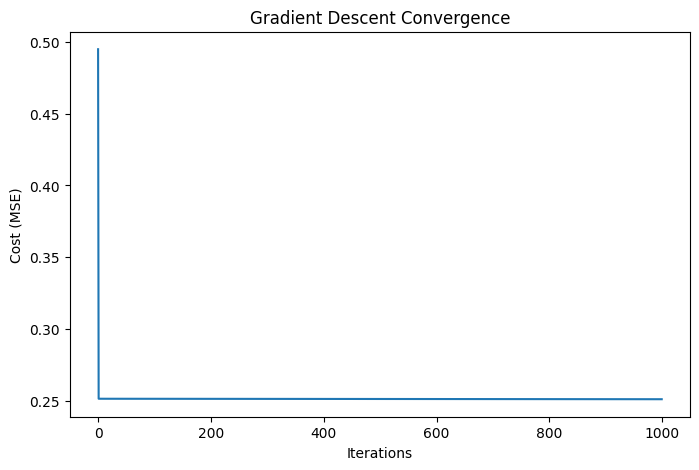

In [37]:
plt.figure(figsize=(8,5))

plt.plot(cost_history)

plt.xlabel("Iterations")
plt.ylabel("Cost (MSE)")
plt.title("Gradient Descent Convergence")

plt.show()

In [38]:
y_test_pred = m * X_test.flatten() + b

In [39]:
mse = mean_squared_error(y_test, y_test_pred)

r2 = r2_score(y_test, y_test_pred)

print("Mean Squared Error =", mse)

print("R2 Score =", r2)

Mean Squared Error = 0.24785545342352705
R2 Score = 0.0036962981669095285


In [40]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_test_pred
})

print(comparison.head(10))

   Actual  Predicted
0       1   0.416917
1       1   0.465846
2       1   0.446886
3       1   0.432207
4       0   0.436489
5       1   0.473797
6       1   0.533735
7       0   0.460341
8       0   0.465846
9       0   0.512328


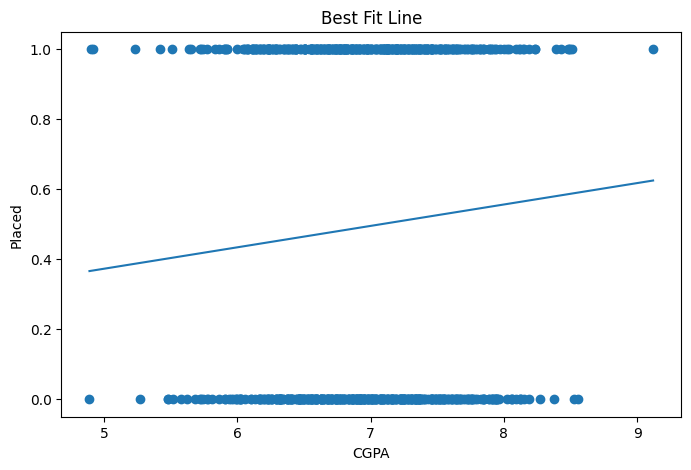

In [41]:
plt.figure(figsize=(8,5))

plt.scatter(
    X_train,
    y_train
)

line_x = np.linspace(
    X_train.min(),
    X_train.max(),
    100
)

line_y = m * line_x + b

plt.plot(line_x, line_y)

plt.xlabel("CGPA")
plt.ylabel("Placed")
plt.title("Best Fit Line")

plt.show()

In [42]:
cgpa = 8.5

prediction = m * cgpa + b

print("Prediction =", prediction)

Prediction = 0.5869447572375357
